## data ingestaion

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mehmetsabrikunt/internet-service-churn")

print("Path to dataset files:", path)

In [ ]:
from pathlib import Path
data_path= Path(path)
for file in data_path.iterdir():
    print(file.name)

In [ ]:
data_path


In [ ]:
import pandas as pd 
data= pd.read_csv(data_path/'internet_service_churn.csv')
data.head()

In [ ]:
output_path= Path("../data/raw")/"internet_service_churn.csv"

data.to_csv(output_path, index=False)

In [ ]:
print(data_path)

## data_transformation


In [3]:
from src.config import RAW_DATA_DIR
import pandas as pd
data= pd.read_csv(RAW_DATA_DIR/"dataset.csv")

In [9]:
data.head()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [4]:
data.columns

Index(['id', 'is_tv_subscriber', 'is_movie_package_subscriber',
       'subscription_age', 'bill_avg', 'reamining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit', 'churn'],
      dtype='object')

In [5]:
data= data.drop(["id"], axis=1)

In [6]:
print(len(data[data["subscription_age"]<0]))

1


In [7]:
for col in data.columns:
    print(f"{col}: {data[col].dtypes}")

is_tv_subscriber: int64
is_movie_package_subscriber: int64
subscription_age: float64
bill_avg: int64
reamining_contract: float64
service_failure_count: int64
download_avg: float64
upload_avg: float64
download_over_limit: int64
churn: int64


In [8]:
for col in data.columns:
    print(f"{col}: {data[col].dtypes}, Nulls: {data[col].isnull().sum()}, Unique: {data[col].nunique()}")

is_tv_subscriber: int64, Nulls: 0, Unique: 2
is_movie_package_subscriber: int64, Nulls: 0, Unique: 2
subscription_age: float64, Nulls: 0, Unique: 1110
bill_avg: int64, Nulls: 0, Unique: 179
reamining_contract: float64, Nulls: 21572, Unique: 247
service_failure_count: int64, Nulls: 0, Unique: 19
download_avg: float64, Nulls: 381, Unique: 2856
upload_avg: float64, Nulls: 381, Unique: 802
download_over_limit: int64, Nulls: 0, Unique: 8
churn: int64, Nulls: 0, Unique: 2


In [15]:
print(data.isnull().sum())

is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             21572
service_failure_count              0
download_avg                     381
upload_avg                       381
download_over_limit                0
churn                              0
dtype: int64


In [16]:
for i , n in enumerate(data.isnull().sum()):
    if n!=0:
        #print(f"{i} {n}")
        print(f"{data.columns[i]}= {round(n/len(data),3)}%")

reamining_contract= 0.298%
download_avg= 0.005%
upload_avg= 0.005%


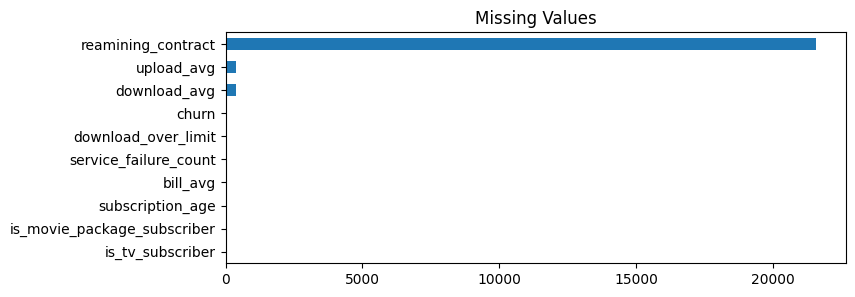

In [18]:
import matplotlib.pyplot as plt
from scipy import stats# Plot
plt.figure(figsize=(8,3))
data.isnull().sum().sort_values(ascending=True).plot(kind='barh')
plt.title("Missing Values")
plt.show()

In [11]:
data["download_over_limit"].unique()

array([0, 3, 7, 2, 5, 1, 6, 4])

In [20]:
data=data.rename(columns={"reamining_contract": "remaining_contract"})

In [21]:
data.groupby(
    data["remaining_contract"].isna()
)["churn"].agg(["count", "mean"])

,count,mean
remaining_contract,,
False,50702,0.400990
True,21572,0.914102


In [24]:
data["remaining_contract"].unique()

array([0.14,  nan, 0.  , 1.38, 1.28, 0.28, 1.8 , 0.01, 0.21, 1.83, 1.82,
       1.85, 1.56, 0.45, 0.44, 1.21, 0.52, 1.1 , 1.2 , 1.66, 0.97, 0.4 ,
       0.46, 0.04, 1.26, 1.74, 1.68, 1.77, 0.12, 1.65, 1.32, 0.33, 1.01,
       1.06, 1.88, 0.99, 1.79, 1.78, 1.93, 1.16, 0.57, 1.95, 1.86, 0.23,
       0.37, 1.96, 0.07, 1.44, 0.15, 0.49, 0.53, 1.27, 1.3 , 1.13, 1.17,
       0.54, 0.1 , 1.43, 1.15, 1.61, 0.27, 0.83, 0.43, 1.02, 0.76, 0.09,
       0.5 , 1.64, 1.  , 0.7 , 1.22, 0.05, 0.65, 0.11, 0.13, 1.62, 1.42,
       0.02, 1.14, 1.34, 1.76, 0.71, 0.17, 1.84, 1.41, 0.24, 0.08, 1.07,
       1.03, 1.5 , 1.89, 1.08, 1.23, 0.29, 0.3 , 0.79, 0.16, 1.12, 0.06,
       1.63, 1.18, 1.67, 0.39, 0.87, 1.05, 1.91, 1.75, 0.25, 1.55, 1.19,
       1.35, 1.53, 0.92, 1.09, 1.58, 0.31, 1.94, 0.93, 0.47, 1.9 , 1.51,
       0.36, 1.59, 0.91, 0.58, 1.97, 1.57, 1.45, 0.18, 0.77, 1.71, 0.82,
       0.78, 1.04, 0.19, 0.88, 0.9 , 1.49, 1.69, 0.38, 1.31, 0.85, 0.22,
       0.55, 0.42, 0.41, 1.11, 1.24, 1.4 , 1.73, 1.

In [29]:
print(f"number of duplicate values: {data.duplicated().sum()/len(data)*100:.2f}%")

number of duplicate values: 0.00%


In [27]:
duplicates = data[data.duplicated()]

print(duplicates)

       is_tv_subscriber  is_movie_package_subscriber  subscription_age  \
37                    0                            0              5.62   
39                    0                            0              5.62   
43                    0                            0              5.62   
59                    0                            0              5.62   
63                    0                            0             11.93   
...                 ...                          ...               ...   
71998                 1                            1              0.61   
72071                 1                            0              0.00   
72134                 0                            0              0.00   
72263                 1                            0              0.02   
72264                 0                            0              0.01   

       bill_avg  remaining_contract  service_failure_count  download_avg  \
37            0                 NaN

In [28]:
data.drop_duplicates(keep='first', inplace=True)

In [ ]:
median_contract = data["remaining_contract"].median()

data["missing_remaining_contract"] = data["remaining_contract"].isna().astype(int)
data["remaining_contract"] = data["remaining_contract"].fillna(median_contract)


In [ ]:
data["download_avg"]= data["download_avg"].fillna(data["download_avg"].median())
data["upload_avg"]= data["upload_avg"].fillna(data["upload_avg"].median())

In [ ]:
  positive_continuous_cols= [,
       'subscription_age', 'bill_avg', 'remaining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit']

def data_cleaning(data):
    data= data.drop(["id"], axis=1)
    data.drop_duplicates(keep='first', inplace=True)
    data=data.rename(columns={"reamining_contract": "remaining_contract"})
    #filling missing values with median
    # negetive values with 0
    data["missing_remaining_contract"]= data["remaining_contract"].isna().astype(int)
    for col in positive_cols:
        data[col]= data[col].fillna(data[col].median())
        data.loc[data[col]<0, col]= 0
    return data

## correlation

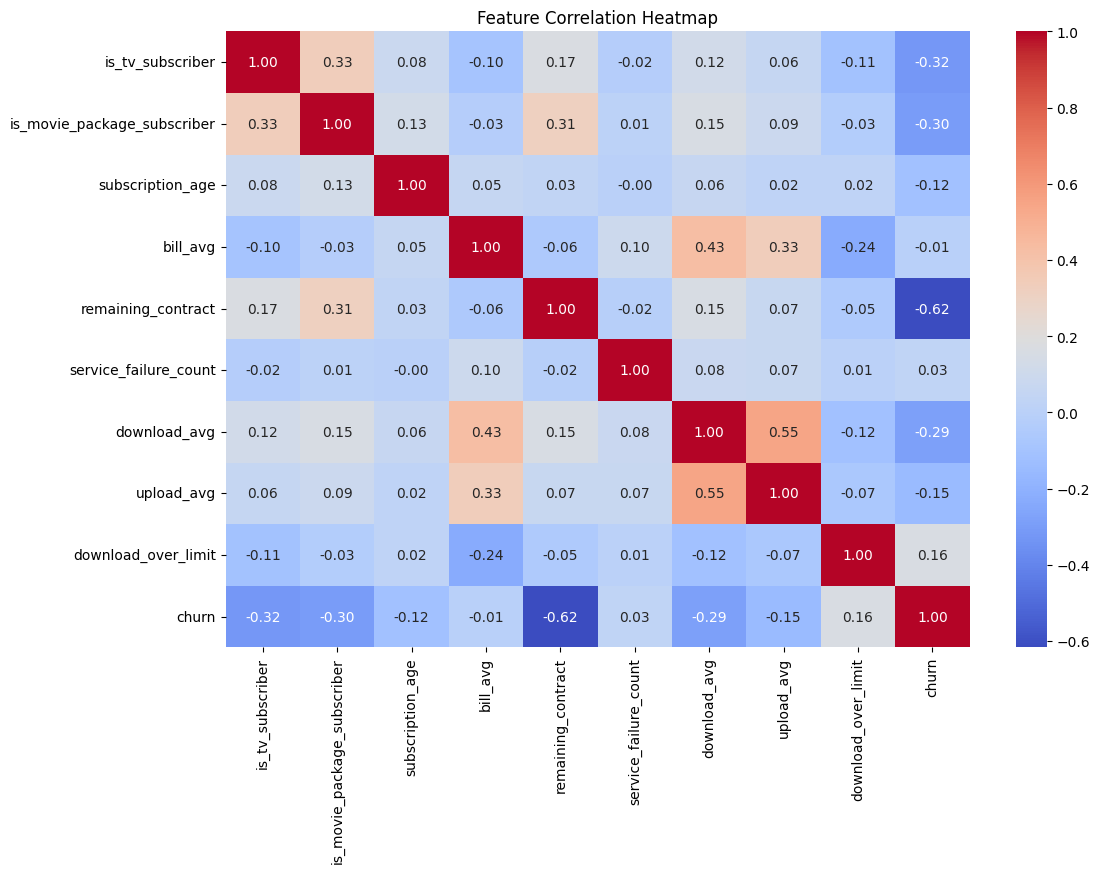

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=data,
    x="churn",
    y="bill_avg"
)

plt.show()

## feature Enginnering

<Axes: >

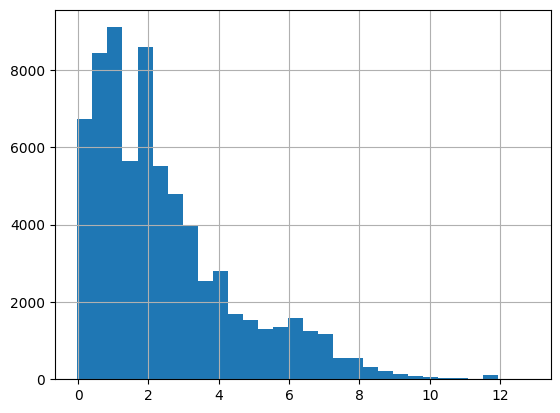

In [35]:
data["subscription_age"].hist(bins=30)


In [ ]:
data["num services subscribed"]= data[["is_tv_subscriber", "is_movie_package_subscriber"]].sum(axis=1)
data["cost_per_usage"]= data["bill_avg"]/data[["download_avg", "upload_avg"]].sum(axis=1)
data["customer_type"]= pd.cut(data["subscription_age"], bins=3, labels=["new","medium", "loyal"])


In [46]:
import numpy as np
total_usage= data[["download_avg", "upload_avg"]].sum(axis=1)
data["cost_per_usage"]= np.where(
    total_usage>0,
    data["bill_avg"]/total_usage,
    0
    )

In [47]:
print(data["cost_per_usage"].mean())
print(data["cost_per_usage"].std())
print(data["cost_per_usage"].min())
print(data["cost_per_usage"].max())

1.4437855498969787
8.668642725733354
0.0
630.0
